In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [4]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
print("Fund Master :", fund_master.shape)
print("NAV :", nav.shape)
print("AUM :", aum.shape)
print("SIP :", sip.shape)
print("Category :", category.shape)
print("Folio :", folio.shape)
print("Performance :", performance.shape)
print("Transactions :", transactions.shape)
print("Portfolio :", portfolio.shape)
print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV : (46000, 3)
AUM : (90, 5)
SIP : (48, 6)
Category : (144, 3)
Folio : (21, 6)
Performance : (40, 19)
Transactions : (32778, 13)
Portfolio : (322, 8)
Benchmark : (8050, 3)


In [6]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Plot NAV trend for all schemes
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    width=1200,
    height=600,
    xaxis_title="Date",
    yaxis_title="NAV",
    showlegend=False
)

fig.show()

## Chart 2: AUM Growth by Fund House (2022–2025)

This chart compares the Assets Under Management (AUM) of different fund houses across years and highlights the growth of the mutual fund industry.

In [9]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Create a Year column
aum["year"] = aum["date"].dt.year

# Group by year and fund house
aum_year = (
    aum.groupby(["year", "fund_house"], as_index=False)["aum_crore"]
    .sum()
)

import plotly.express as px

fig = px.bar(
    aum_year,
    x="year",
    y="aum_crore",
    color="fund_house",
    barmode="group",
    title="AUM Growth by Fund House (2022–2025)"
)

fig.update_layout(
    width=1200,
    height=600,
    xaxis_title="Year",
    yaxis_title="AUM (₹ Crore)"
)

fig.show()

## Chart 3: Monthly SIP Inflow Trend (2022–2025)

This chart shows the monthly SIP inflows from January 2022 to December 2025 and highlights the growth of systematic investments.

In [10]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


## Chart 3: Monthly SIP Inflow Trend (2022–2025)

This chart shows the monthly SIP inflows from January 2022 to December 2025 and highlights the all-time high SIP inflow.

In [11]:
# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Create line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

# Highlight the maximum SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Highest: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    width=1200,
    height=600,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [12]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


## Chart 4: Category-wise Net Inflow Heatmap

This heatmap shows the monthly net inflow across different mutual fund categories.

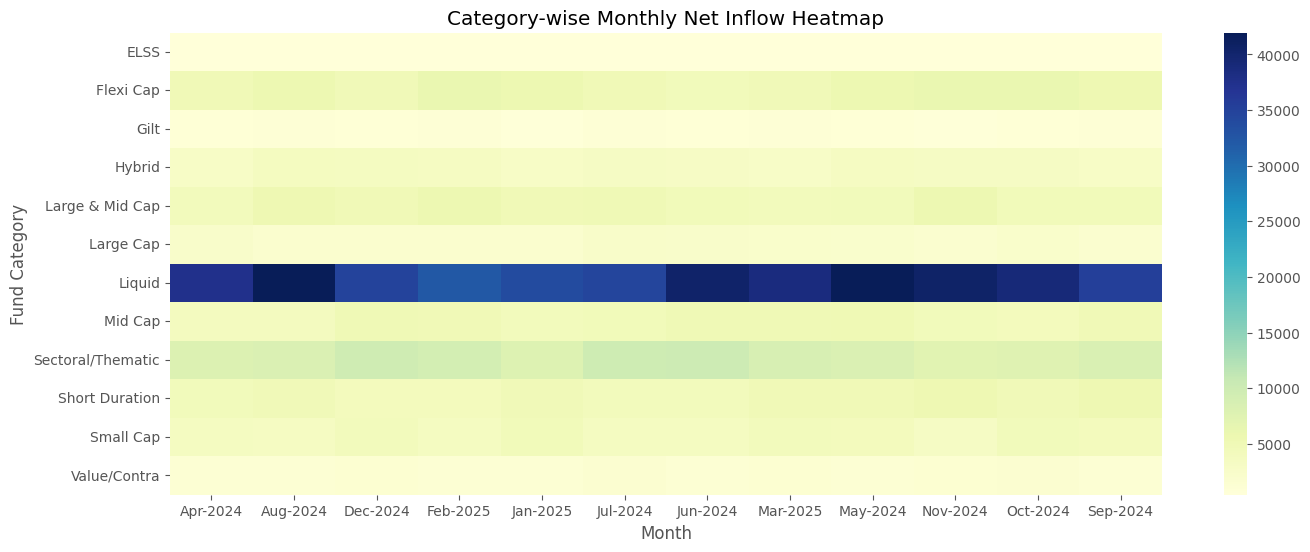

In [13]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Convert month to Month-Year format
category["Month"] = category["month"].dt.strftime("%b-%Y")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="Month",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

## Chart 5: Investor Demographics

This section analyzes the demographic profile of investors including age groups, investment amount distribution, and gender composition.

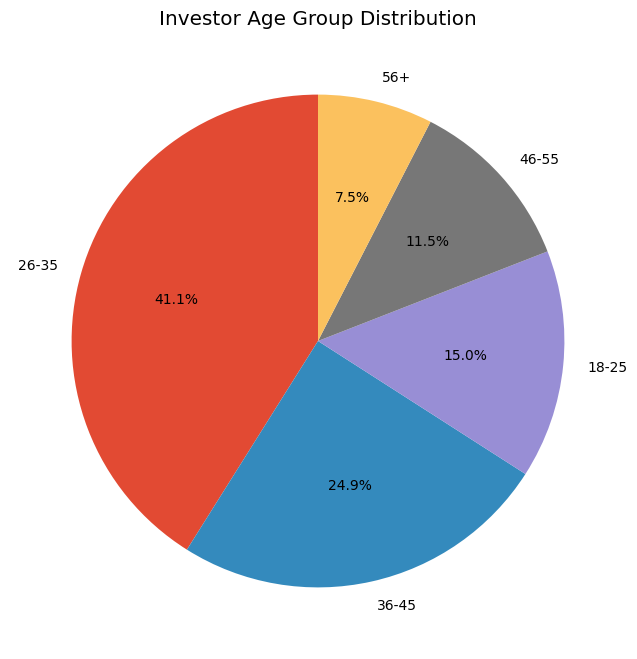

In [14]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.show()

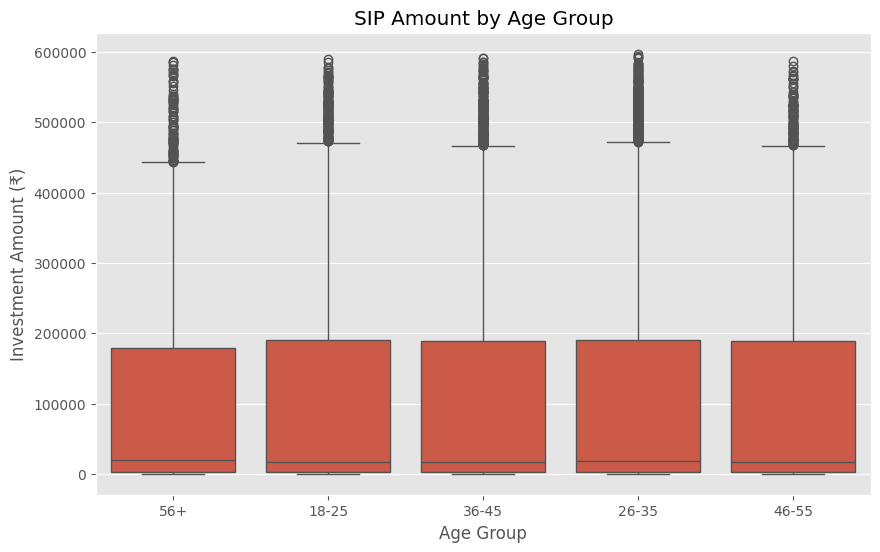

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.show()

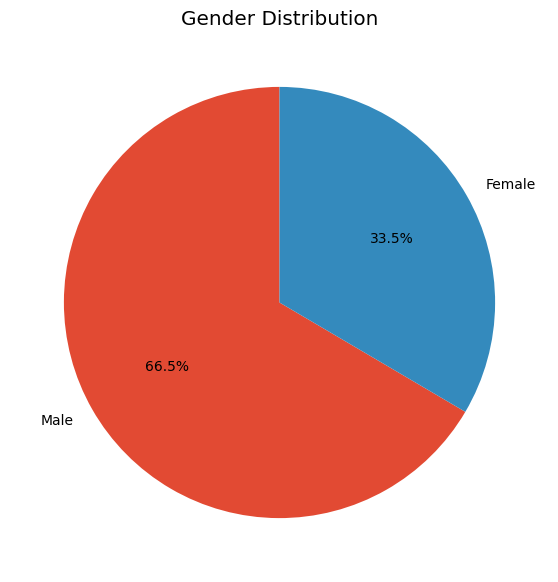

In [16]:
plt.figure(figsize=(7,7))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

## Chart 6: Geographic Distribution

This section analyzes the geographic distribution of mutual fund investments across Indian states and city tiers.

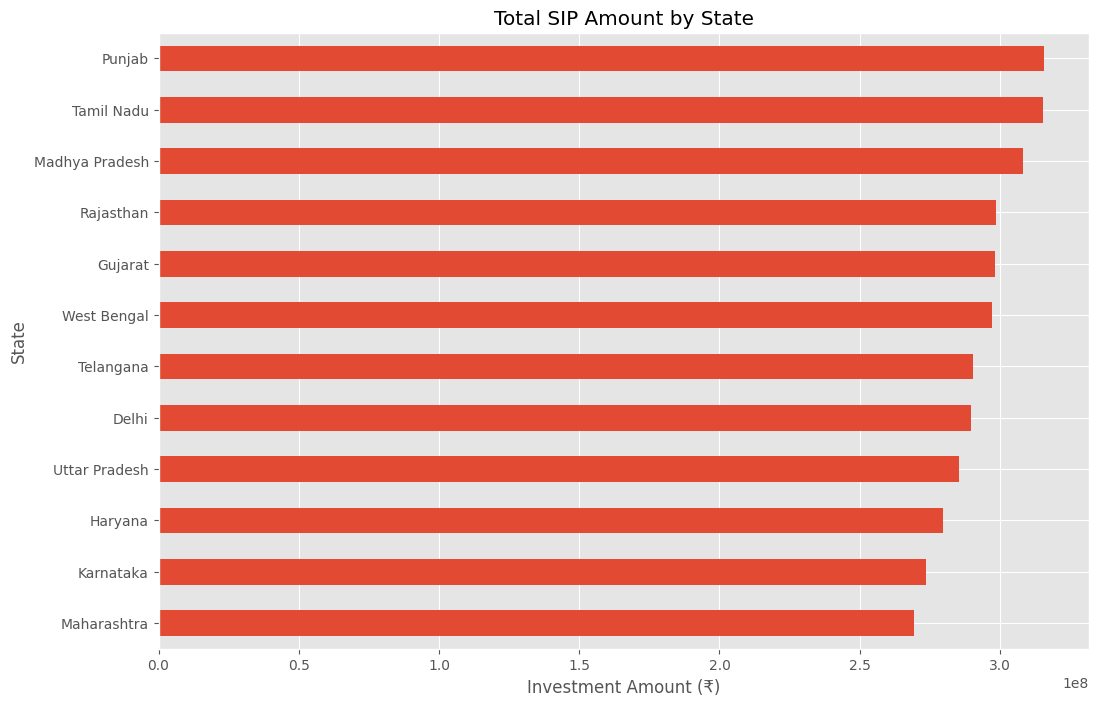

In [17]:
# Total SIP Amount by State
state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.show()

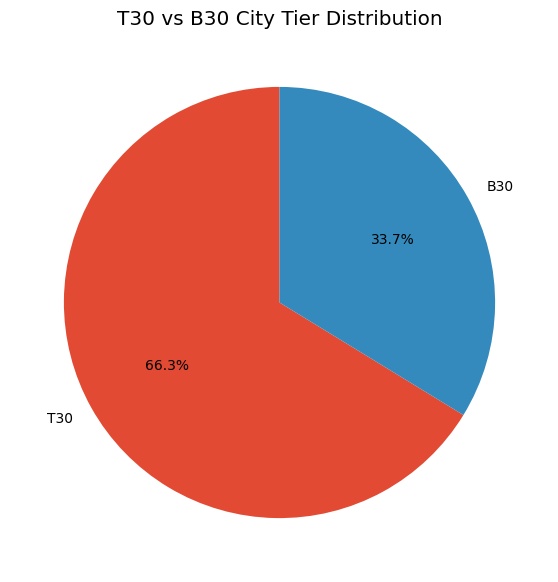

In [18]:
plt.figure(figsize=(7,7))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")
plt.ylabel("")

plt.show()

## Chart 7: Folio Count Growth (2022–2025)

This chart shows the growth in mutual fund folio counts from January 2022 to December 2025.

In [19]:
print(folio.columns)


Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


## Chart 7: Folio Count Growth (2022–2025)

This chart shows the growth in total mutual fund folios from January 2022 to December 2025.

In [20]:
# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

# Create line chart
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Growth of Mutual Fund Folios (2022–2025)",
    markers=True
)

# Mark the first point (Jan 2022)
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text=f"Start: {folio.iloc[0]['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

# Mark the last point (Dec 2025)
fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text=f"End: {folio.iloc[-1]['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    width=1200,
    height=600,
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

fig.show()

In [21]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [22]:
print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [23]:
print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='object')


## Chart 8: Mutual Fund Return Correlation Matrix

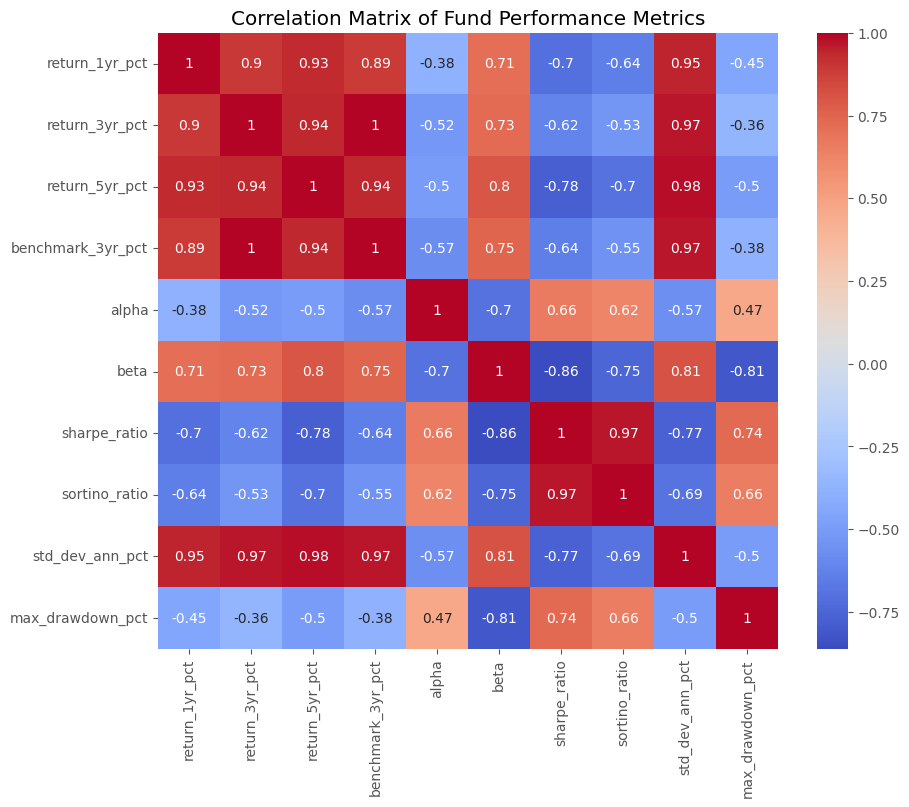

In [24]:
# Select 10 funds
top10 = performance.head(10)

corr = top10[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "benchmark_3yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio",
        "sortino_ratio",
        "std_dev_ann_pct",
        "max_drawdown_pct"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Fund Performance Metrics")

plt.show()

## Chart 9: Sector Allocation

In [25]:
sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
)

fig = px.pie(
    values=sector_data.values,
    names=sector_data.index,
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.show()

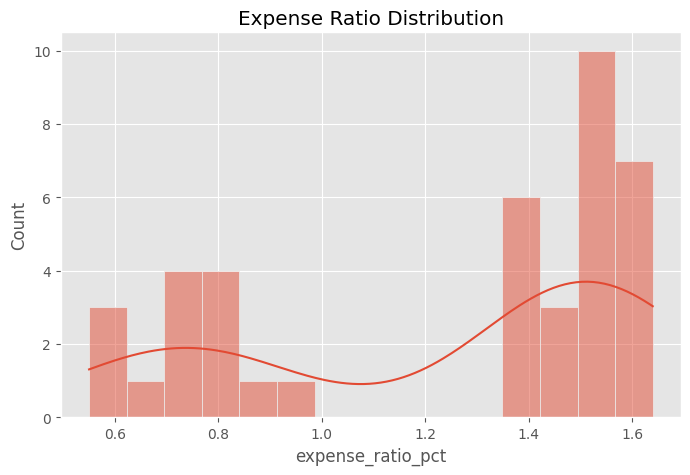

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

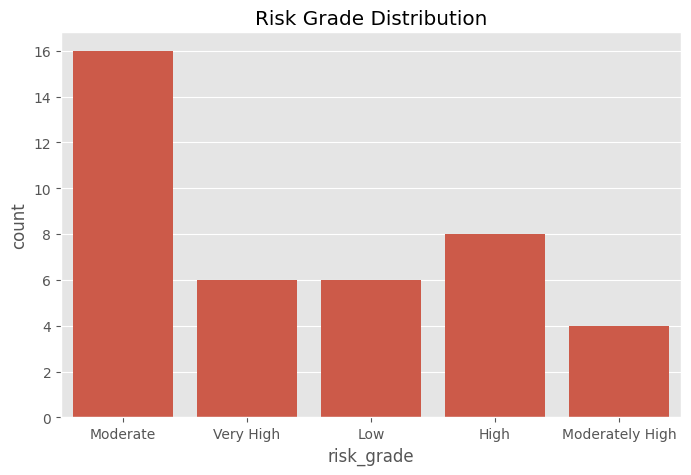

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.show()

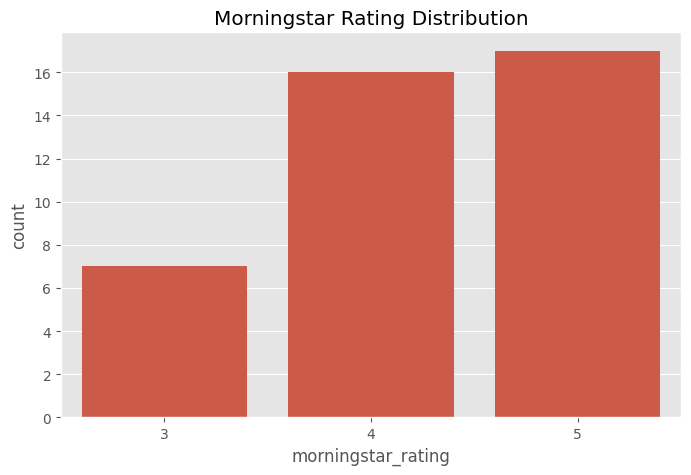

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.show()

In [29]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

fig = px.line(
    benchmark,
    x="date",
    y="close_value",
    color="index_name",
    title="Benchmark Index Performance"
)

fig.show()

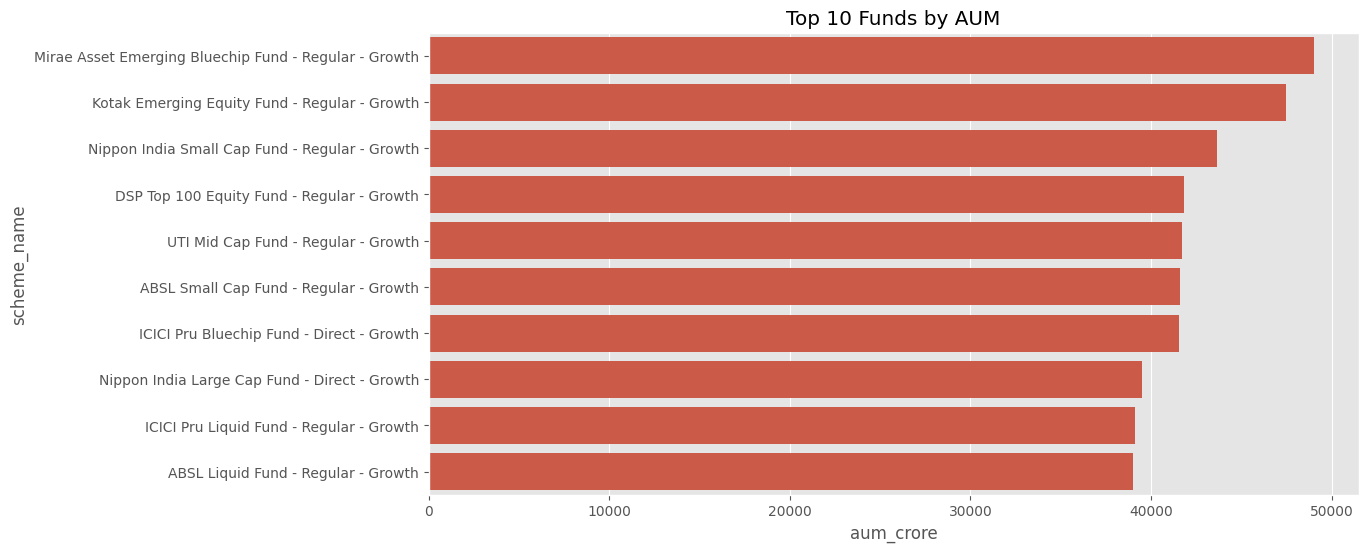

In [30]:
topfunds = performance.nlargest(
    10,
    "aum_crore"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=topfunds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")

plt.show()

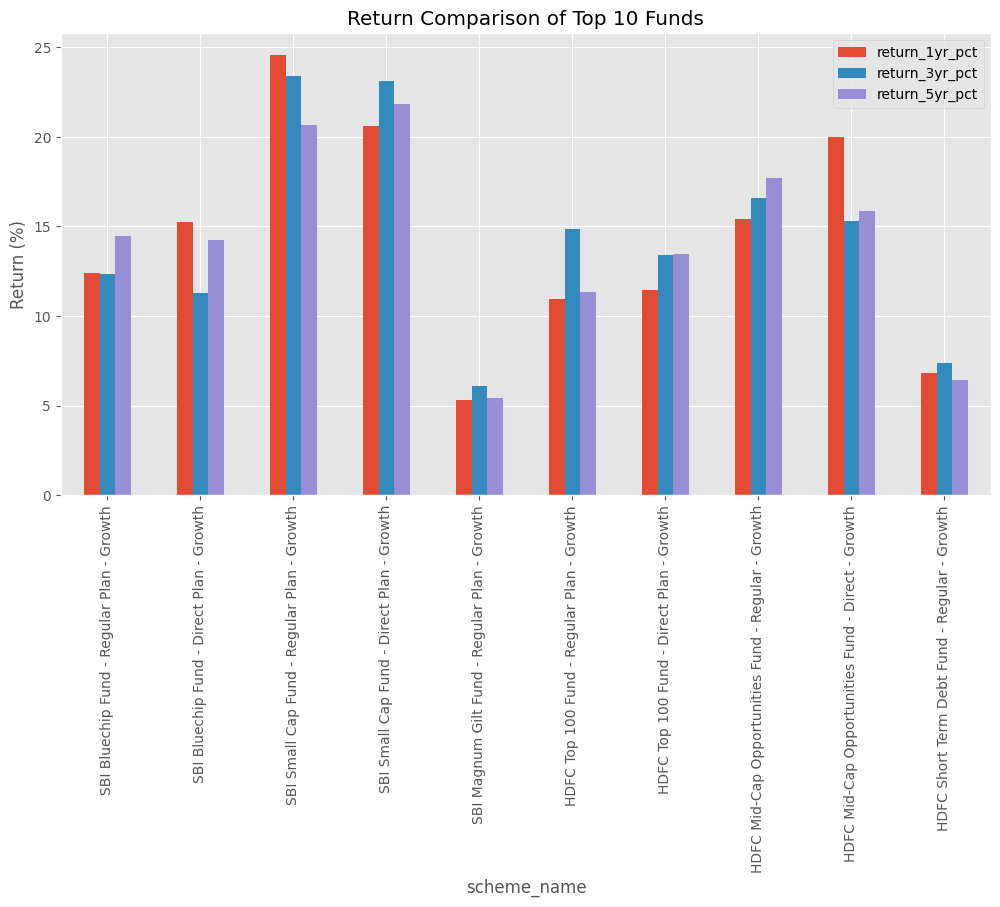

In [31]:
returns = performance[
    [
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].head(10)

returns = returns.set_index(
    "scheme_name"
)

returns.plot(
    figsize=(12,6),
    kind="bar"
)

plt.title("Return Comparison of Top 10 Funds")

plt.ylabel("Return (%)")

plt.show()

### Finding 1
Daily NAV values generally increased over the analysis period, indicating long-term growth in mutual fund investments.

### Finding 2
AUM has consistently increased across most fund houses, showing industry expansion.

### Finding 3
Monthly SIP inflows reached their highest value toward the end of the study period.

### Finding 4
Certain mutual fund categories consistently attracted higher net inflows than others.

### Finding 5
The majority of investors belong to middle-age groups.

### Finding 6
Investment amounts vary considerably across different age groups.

### Finding 7
T30 cities contribute a larger share of investments than B30 cities.

### Finding 8
Total mutual fund folios increased steadily between 2022 and 2025.

### Finding 9
Technology and Financial sectors account for a significant portion of portfolio allocations.

### Finding 10
Funds with lower expense ratios generally demonstrate competitive long-term returns.